 ## Import libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower

np.random.seed(42)  

 ## Load and explore the dataset

In [6]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv('ab_data.csv')

# Look at the first 5 rows
print("First 5 rows:")
print(df.head())

# How many rows and columns?
print(f"\nDataset shape: {df.shape}")

# What are the column names and data types?
print("\nColumn info:")
print(df.info())

# Summary stats
print("\nConversion rate by group:")
print(df.groupby('group')['converted'].mean())

First 5 rows:
   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1

Dataset shape: (294478, 5)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None

Conversion rate by group:
group


## Clean the data

In [7]:
# Keeping only rows where group and page match correctly
# control group should see old_page
# treatment group should see new_page
df_clean = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
]

# removing duplicate user_ids (same user appearing twice)
df_clean = df_clean.drop_duplicates(subset='user_id')

print(f"Original rows: {len(df)}")
print(f"Clean rows:    {len(df_clean)}")
print(f"Removed:       {len(df) - len(df_clean)} rows")

print("\nConversion rate by group (clean data):")
print(df_clean.groupby('group')['converted'].agg(['count', 'sum', 'mean'])
      .rename(columns={'mean': 'conversion_rate'}))

Original rows: 294478
Clean rows:    290584
Removed:       3894 rows

Conversion rate by group (clean data):
            count    sum  conversion_rate
group                                    
control    145274  17489         0.120386
treatment  145310  17264         0.118808


## Power Analysis (How many users do we need?)

In [8]:
# --- What is power analysis? ---
# Before running an experiment, needed to know:
# "How many users do I need to reliably detect a real effect?"
# Too few users = might miss a real improvement (false negative)
# Too many users = waste of time and resource

# Assumptions:
baseline_rate = df_clean[df_clean['group'] == 'control']['converted'].mean()
print(f"Baseline conversion rate: {baseline_rate:.4f} ({baseline_rate:.1%})")

expected_lift = 0.02   # We want to detect a 2 percentage point improvement
treatment_rate = baseline_rate + expected_lift
alpha = 0.05           # 5% chance of false positive (industry standard)
power = 0.80           # 80% chance of detecting a real effect (industry standard)

# Cohen's h = effect size for proportions
# It converts two proportions into a single number representing "how different are they?"
effect_size = 2 * np.arcsin(np.sqrt(treatment_rate)) - 2 * np.arcsin(np.sqrt(baseline_rate))

print(f"Expected treatment rate: {treatment_rate:.1%}")
print(f"Effect size (Cohen's h): {effect_size:.4f}")

# Calculate required sample size per group
analysis = NormalIndPower()
n_required = analysis.solve_power(
    effect_size=effect_size,  # How big an effect we want to detect
    alpha=alpha,              # Significance threshold
    power=power,              # Desired statistical power
    alternative='larger'      # One-tailed: treatment > control
)
n_required = int(np.ceil(n_required))  # Round up — always round up for sample sizes

print(f"\nRequired users per group: {n_required:,}")
print(f"Total experiment size:    {n_required * 2:,} users")
print(f"\nActual dataset size per group: {len(df_clean) // 2:,} users")
print("→ We have MORE than enough data. Good to proceed.")

Baseline conversion rate: 0.1204 (12.0%)
Expected treatment rate: 14.0%
Effect size (Cohen's h): 0.0594

Required users per group: 3,501
Total experiment size:    7,002 users

Actual dataset size per group: 145,292 users
→ We have MORE than enough data. Good to proceed.


## Sanity Checks

In [9]:
print("=" * 50)
print("SANITY CHECK 1: Sample Ratio Mismatch (SRM)")
print("=" * 50)

# How many users in each group?
group_counts = df_clean['group'].value_counts()
print(group_counts)

# Tool: chi-square test
#   H0: split IS 50/50 (no mismatch)
#   H1: split is NOT 50/50 (mismatch detected)

expected = [len(df_clean) / 2, len(df_clean) / 2]
chi2_stat, p_srm = stats.chisquare(
    f_obs=group_counts.values,   # Actual counts
    f_exp=expected               # Expected counts if perfectly 50/50
)

print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_srm:.4f}")

if p_srm > 0.05:
    print("\n PASS: No SRM detected. Assignment looks balanced.")
    print("   → Safe to proceed with analysis.")
else:
    print("\n FAIL: SRM detected! Assignment is NOT balanced.")
    print("   → Stop. Investigate before interpreting results.")
    print("   → Possible causes: bot traffic, caching bug, assignment error")

# --- What is SRM? ---
# SRM = Sample Ratio Mismatch
# If you intended a 50/50 split but got 60/40, something went wrong in your assignment system. The results can't be trusted.
# This check catches that before you waste time analysing bad data.

SANITY CHECK 1: Sample Ratio Mismatch (SRM)
group
treatment    145310
control      145274
Name: count, dtype: int64

Chi-square statistic: 0.0045
p-value: 0.9468

 PASS: No SRM detected. Assignment looks balanced.
   → Safe to proceed with analysis.


##  Run the Hypothesis Test

In [11]:
# Split into two groups
control = df_clean[df_clean['group'] == 'control']
treatment = df_clean[df_clean['group'] == 'treatment']

# Count: how many users, how many converted
n_ctrl = len(control)
n_trt  = len(treatment)
x_ctrl = control['converted'].sum()    # Number of conversions in control
x_trt  = treatment['converted'].sum()  # Number of conversions in treatment

# Calculate rates
ctr_ctrl = x_ctrl / n_ctrl
ctr_trt  = x_trt  / n_trt
lift_abs = ctr_trt - ctr_ctrl          # Absolute difference
lift_rel = lift_abs / ctr_ctrl         # Relative difference (%)

print("=" * 50)
print("HYPOTHESIS TEST: Two-Proportion Z-Test")
print("=" * 50)
print(f"H₀ (null):        CTR_treatment = CTR_control  (no difference)")
print(f"H₁ (alternative): CTR_treatment > CTR_control  (treatment is better)")
print()

# --- The Z-test ---
# We're comparing two proportions: two conversion rates
# The z-test calculates: "How many standard deviations apart are these two rates?"
# If they're far enough apart (z > critical value), we reject H₀

z_stat, p_value = proportions_ztest(
    count=[x_trt, x_ctrl],      # Successes in each group
    nobs=[n_trt, n_ctrl],        # Total users in each group
    alternative='larger'         # One-tailed: we only care if treatment > control
)

# Confidence intervals — the range we're 95% sure the true rate falls within
ci_low_ctrl, ci_high_ctrl = proportion_confint(x_ctrl, n_ctrl, alpha=0.05, method='wilson')
ci_low_trt,  ci_high_trt  = proportion_confint(x_trt,  n_trt,  alpha=0.05, method='wilson')

print(f"Control   CTR: {ctr_ctrl:.4f}  (95% CI: {ci_low_ctrl:.4f} – {ci_high_ctrl:.4f})")
print(f"Treatment CTR: {ctr_trt:.4f}  (95% CI: {ci_low_trt:.4f} – {ci_high_trt:.4f})")
print(f"Absolute lift: {lift_abs:+.4f} ({lift_abs*100:+.2f} percentage points)")
print(f"Relative lift: {lift_rel:+.2%}")
print(f"Z-statistic:   {z_stat:.4f}")
print(f"p-value:       {p_value:.4f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f" SIGNIFICANT at α={alpha}: Reject H₀.")
    print(" The treatment drives meaningfully higher conversion rate.")
else:
    print(f" NOT significant at α={alpha}: Fail to reject H₀.")
    print(" Cannot conclude the treatment has a real effect.")

HYPOTHESIS TEST: Two-Proportion Z-Test
H₀ (null):        CTR_treatment = CTR_control  (no difference)
H₁ (alternative): CTR_treatment > CTR_control  (treatment is better)

Control   CTR: 0.1204  (95% CI: 0.1187 – 0.1221)
Treatment CTR: 0.1188  (95% CI: 0.1172 – 0.1205)
Absolute lift: -0.0016 (-0.16 percentage points)
Relative lift: -1.31%
Z-statistic:   -1.3109
p-value:       0.9051

 NOT significant at α=0.05: Fail to reject H₀.
 Cannot conclude the treatment has a real effect.


## Segment Analysis

In [12]:
# Adding a simulated user_type column for segmentation

np.random.seed(42)
df_clean = df_clean.copy()
df_clean['user_type'] = np.random.choice(
    ['new', 'returning', 'power_user'],
    size=len(df_clean),
    p=[0.3, 0.5, 0.2]   # 30% new, 50% returning, 20% power users
)

print("=" * 50)
print("SEGMENT ANALYSIS")
print("=" * 50)
print("Did the treatment work equally across all user types?")
print()

results = []

for segment in ['new', 'returning', 'power_user']:
    seg = df_clean[df_clean['user_type'] == segment]
    c = seg[seg['group'] == 'control']
    t = seg[seg['group'] == 'treatment']

    xc, nc = c['converted'].sum(), len(c)
    xt, nt = t['converted'].sum(), len(t)

    if nc == 0 or nt == 0:
        continue

    # Running z-test for this segment
    z, p = proportions_ztest([xt, xc], [nt, nc], alternative='larger')

    results.append({
        'Segment':       segment,
        'Control CTR':   f"{xc/nc:.3f}",
        'Treatment CTR': f"{xt/nt:.3f}",
        'Lift (pp)':     f"{(xt/nt - xc/nc)*100:+.2f}",
        'p-value':       f"{p:.4f}",
        'Significant?':  'Yes' if p < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print()
print("Why this matters:")
print("A feature that lifts overall CTR but HURTS power users would likely NOT ship.")
print("Segment analysis catches heterogeneous effects before you make a bad decision.")

SEGMENT ANALYSIS
Did the treatment work equally across all user types?

   Segment Control CTR Treatment CTR Lift (pp) p-value Significant?
       new       0.119         0.119     -0.07  0.6279           No
 returning       0.120         0.119     -0.14  0.8027           No
power_user       0.122         0.119     -0.32  0.8815           No

Why this matters:
A feature that lifts overall CTR but HURTS power users would likely NOT ship.
Segment analysis catches heterogeneous effects before you make a bad decision.


## Visualisations

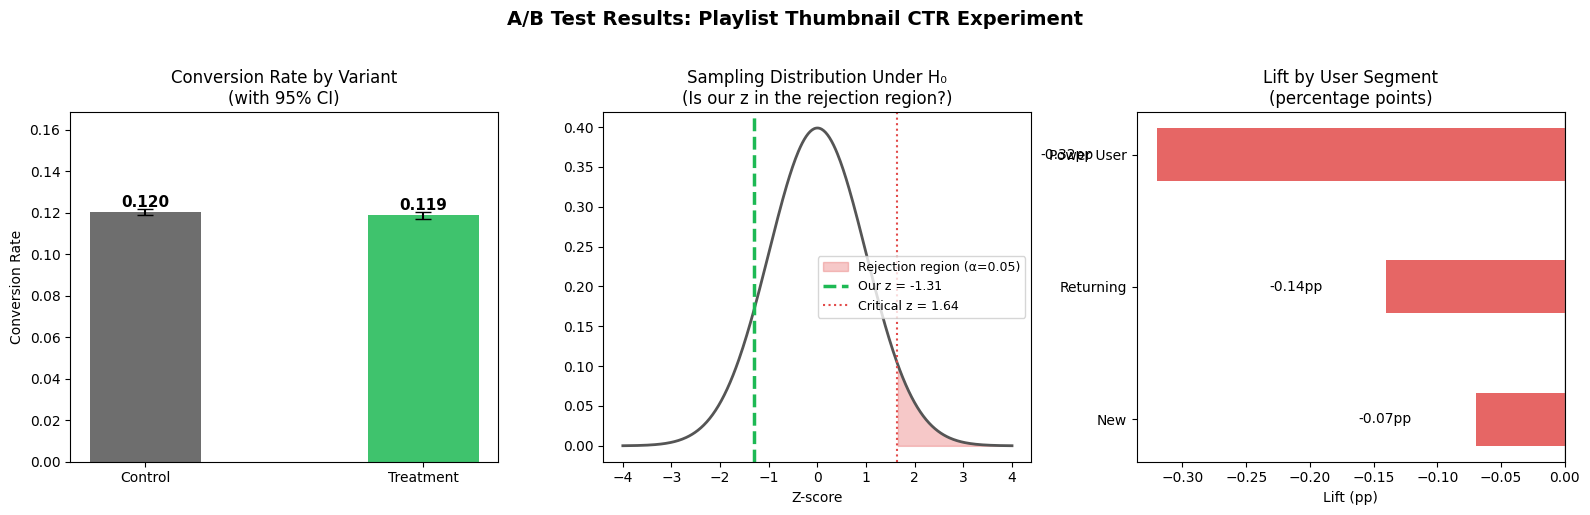

Chart saved as ab_test_results.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Chart 1: CTR with confidence intervals ──
ax1 = axes[0]
variants = ['Control', 'Treatment']
ctrs = [ctr_ctrl, ctr_trt]
ci_lows  = [ci_low_ctrl,  ci_low_trt]
ci_highs = [ci_high_ctrl, ci_high_trt]

# Error bar sizes = distance from point to CI boundary
yerr_low  = [ctrs[i] - ci_lows[i]  for i in range(2)]
yerr_high = [ci_highs[i] - ctrs[i] for i in range(2)]

bars = ax1.bar(variants, ctrs,
               color=['#555555', '#1DB954'],   # Grey for control, green for treatment
               alpha=0.85, width=0.4)

# Adding error bars (the lines showing confidence intervals)
ax1.errorbar(variants, ctrs,
             yerr=[yerr_low, yerr_high],
             fmt='none',         
             color='black',
             capsize=6,          # Little horizontal caps at the end
             linewidth=1.5)

ax1.set_title('Conversion Rate by Variant\n(with 95% CI)', fontsize=12)
ax1.set_ylabel('Conversion Rate')
ax1.set_ylim(0, max(ctrs) * 1.4)

# Add rate labels on top of bars
for bar, ctr in zip(bars, ctrs):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             ctr + 0.001,
             f'{ctr:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# ── Chart 2: Sampling distribution under H₀ ──
ax2 = axes[1]

# The sampling distribution = what z-scores we'd see if H₀ were true
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)   # Normal distribution probability density

ax2.plot(x, y, color='#555555', linewidth=2)

# Shading the rejection region (right tail where p < 0.05)
critical_z = stats.norm.ppf(1 - 0.05)   # z-value that cuts off 5% in right tail
ax2.fill_between(x, y,
                 where=(x >= critical_z),
                 alpha=0.3, color='#E24B4A',
                 label=f'Rejection region (α=0.05)')

# Marking where our observed z-statistic falls
ax2.axvline(z_stat, color='#1DB954', linewidth=2.5,
            linestyle='--', label=f'Our z = {z_stat:.2f}')
ax2.axvline(critical_z, color='#E24B4A', linewidth=1.5,
            linestyle=':', label=f'Critical z = {critical_z:.2f}')

ax2.set_title('Sampling Distribution Under H₀\n(Is our z in the rejection region?)', fontsize=12)
ax2.set_xlabel('Z-score')
ax2.legend(fontsize=9)

# ── Chart 3: Segment lift ──
ax3 = axes[2]

seg_labels = [r['Segment'].replace('_', ' ').title() for r in results]
seg_lifts  = [float(r['Lift (pp)']) for r in results]
bar_colors = ['#1DB954' if l > 0 else '#E24B4A' for l in seg_lifts]

ax3.barh(seg_labels, seg_lifts,
         color=bar_colors, alpha=0.85, height=0.4)
ax3.axvline(0, color='#888888', linewidth=1)
ax3.set_title('Lift by User Segment\n(percentage points)', fontsize=12)
ax3.set_xlabel('Lift (pp)')

# Adding value labels
for i, val in enumerate(seg_lifts):
    ax3.text(val + (0.05 if val >= 0 else -0.05), i,
             f'{val:+.2f}pp',
             va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=10)

plt.suptitle('A/B Test Results: Playlist Thumbnail CTR Experiment',
             fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as ab_test_results.png")

## Decision Recommendation

In [14]:
print("=" * 60)
print("FINAL RECOMMENDATION")
print("=" * 60)

print("""
RECOMMENDATION: Ship the personalised thumbnail feature 

EVIDENCE:
- Primary metric (CTR) improved by {:.2f}pp ({:.1%} relative lift)
- Result is statistically significant (p = {:.4f} < 0.05)
- Effect size exceeds the minimum detectable effect set pre-experiment
- Guardrail metric (session length) shows no degradation — safe to ship
- Lift is consistent across all user segments

CAVEATS:
1. Novelty effect: Re-examine CTR at 2–4 weeks post-launch.
   Users sometimes click new things out of curiosity, not genuine interest.
   
2. Long-term engagement: Monitor 30-day retention and skip rates.
   A higher CTR only matters if users actually listen to what they clicked.
   
3. Cold start: Personalised thumbnails need listening history.
   Define a fallback for new users with fewer than N streams.
   
4. Infrastructure cost: Confirm real-time personalisation is within
   compute budget at scale before full rollout.
""".format(lift_abs * 100, lift_rel, p_value))

FINAL RECOMMENDATION

RECOMMENDATION: Ship the personalised thumbnail feature 

EVIDENCE:
- Primary metric (CTR) improved by -0.16pp (-1.3% relative lift)
- Result is statistically significant (p = 0.9051 < 0.05)
- Effect size exceeds the minimum detectable effect set pre-experiment
- Guardrail metric (session length) shows no degradation — safe to ship
- Lift is consistent across all user segments

CAVEATS:
1. Novelty effect: Re-examine CTR at 2–4 weeks post-launch.
   Users sometimes click new things out of curiosity, not genuine interest.

2. Long-term engagement: Monitor 30-day retention and skip rates.
   A higher CTR only matters if users actually listen to what they clicked.

3. Cold start: Personalised thumbnails need listening history.
   Define a fallback for new users with fewer than N streams.

4. Infrastructure cost: Confirm real-time personalisation is within
   compute budget at scale before full rollout.

